# Differential marker panel across 45 cell-level clusters

Prototype notebook for testing whether a compact marker panel reveals block-like transcriptional structure across the 45 SFUMATO cell-level clusters.

Main idea:
- use the existing cell-level `.h5ad` file for a fast feasibility run;
- keep only high-confidence assignments using `p1 >= threshold`;
- compute cluster-level gene profiles;
- select a compact global marker panel, now defaulting to **30 markers total**;
- visualize **genes on rows** and **clusters on columns**;
- annotate cluster columns with the SFUMATO colors;
- order clusters and markers data-driven to reveal possible block-like structure;
- optionally generate small spatial maps for each inferred block, with block clusters colored and all other clusters in light grey.

Important note: this is a prototype based on high-confidence hard assignments. A fully probability-weighted version can be enabled later when the final transcript-level probability table is available.


In [1]:
# If needed, install these in the environment where the notebook will be run:
# pip install anndata scanpy pandas numpy scipy matplotlib seaborn statsmodels

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy import sparse
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact

try:
    import anndata as ad
except ImportError as e:
    raise ImportError("Please install anndata or scanpy before running this notebook.") from e

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    warnings.warn("statsmodels not available: adjusted p-values will be skipped.")

sns.set_theme(style="white", context="paper")

## 1. Configuration

Set the input path and column names here. The notebook tries to infer common column names, but for the final run it is safer to set them explicitly.

Expected quick prototype mode:
- `ASSIGNMENT_MODE = "thresholded"`
- `P1_THRESHOLD = 0.8`
- if the file stores complementary uncertainty, use `COMPL_P1_COL`, and the notebook computes `p1 = 1 - compl_p1`.

The future probability-weighted mode is intentionally kept as a placeholder because it requires the full transcript-level probability table, which may have a different structure from the current `.h5ad`.

In [2]:
# Input/output
ADATA_PATH = Path(r"full\newcolors\mousexeniumcell_BGM68to45_BIN7_F5_SVD10_FULL.h5ad")
OUTPUT_DIR = Path("./dge_cell_level_45_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Analysis mode
ASSIGNMENT_MODE = "thresholded"  # "thresholded", "hard_all", or future "weighted"
P1_THRESHOLD = 0.8

# Marker panel
TOP_N_MARKERS_TOTAL = 45
MARKER_SELECTION_MODE = "balanced_global"
# Options:
# - "balanced_global": compact global panel with a cap per best cluster. Good for the main block figure.
# - "global_top": top genes globally, no balancing. Can be dominated by a few clusters.
# - "per_cluster": K markers per cluster. Useful for atlas/QC, usually too many genes for the main figure.
MAX_MARKERS_PER_BEST_CLUSTER = 2
MARKERS_PER_CLUSTER = 2
N_BLOCKS_FOR_DIAGONAL = None  # set to 4, 5, 6... to force the number of cluster blocks
MIN_LOG2FC = 0.25
MIN_BEST_CLUSTER_FRACTION = 1e-5
MIN_SPECIFICITY = 0.05
PSEUDOCOUNT = 0.5

# Optional p-value calculation for the strongest candidate gene-cluster pairs.
# Set to 0 for a faster purely effect-size-based prototype.
COMPUTE_PVALUES_FOR_TOP_N_PAIRS = 3000

# Column names: fill these explicitly for your file.
# The notebook intentionally does not guess these names anymore.
CLUSTER_COL = "cluster"      # e.g. "cluster_45", "hard_cluster"
GENE_COL = "target_name"               # for transcript-table-like h5ad, e.g. "gene", "feature_name"
P1_COL = None                    # e.g. "p1"
COMPL_P1_COL = "compl_p1"       # e.g. "compl_p1"; p1 = 1 - compl_p1
COLOR_COL = "color_hard_hsv"    # e.g. "color_hard_hsv"
X_COL = "x"                     # e.g. "x", "global_x", "imagecol"
Y_COL = "y"                     # e.g. "y", "global_y", "imagerow"
SAMPLE_COL = None                # optional, e.g. "sample", "fov", "slide"

# AnnData matrix mode settings, used only if genes are in adata.var and expression is in X/layer.
EXPRESSION_LAYER = None  # e.g. "counts", "log1p"; None uses adata.X
USE_RAW_IF_AVAILABLE = False


# Dendrogram-aligned cluster order
# This is the left-to-right K=45 order from the shared dendrogram cut.
# Use strings without the C prefix; the code also accepts adata cluster labels like C0, C1, ...
DENDROGRAM_CLUSTER_ORDER = [
    "0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11",
    "12", "14", "13", "15", "16", "17", "18", "19", "20", "22", "21",
    "24", "23", "25", "26", "27", "28", "29", "30", "32", "31", "33",
    "34", "35", "37", "36", "38", "39", "40", "43", "42", "41", "44",
]

# Plot settings
FIG_DPI = 300
HEATMAP_CMAP = "vlag"
BACKGROUND_GREY = "#d9d9d9"
RANDOM_SEED = 7
MAX_POINTS_PER_SPATIAL_PANEL = 150_000

np.random.seed(RANDOM_SEED)


## 2. Helper functions

In [3]:
def first_existing_column(df, candidates, explicit=None, required=False, label="column"):
    if explicit is not None:
        if explicit not in df.columns:
            raise KeyError(f"Requested {label} '{explicit}' was not found. Available columns include: {list(df.columns[:30])}")
        return explicit
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Could not infer {label}. Tried: {candidates}. Available columns include: {list(df.columns[:30])}")
    return None


def parse_color(value):
    # Return a valid hex color from common stored formats. color_hard_hsv is treated as stored hex/RGB despite the obsolete name.
    if pd.isna(value):
        return None
    if isinstance(value, str):
        text = value.strip()
        if text.startswith("#"):
            return text
        if text.startswith("(") and text.endswith(")"):
            try:
                vals = [float(x.strip()) for x in text.strip("()").split(",")]
                if len(vals) >= 3:
                    vals = vals[:3]
                    if max(vals) > 1:
                        vals = [v / 255 for v in vals]
                    return to_hex(vals)
            except Exception:
                pass
        try:
            return to_hex(to_rgb(text))
        except Exception:
            return None
    if isinstance(value, (tuple, list, np.ndarray)) and len(value) >= 3:
        vals = [float(v) for v in value[:3]]
        if max(vals) > 1:
            vals = [v / 255 for v in vals]
        return to_hex(vals)
    return None


def generated_cluster_colors(clusters):
    palette = sns.color_palette("husl", n_colors=len(clusters))
    return {cluster: to_hex(color) for cluster, color in zip(clusters, palette)}


def get_cluster_colors(obs, cluster_col, color_col, clusters):
    generated = generated_cluster_colors(clusters)
    if color_col is None or color_col not in obs.columns:
        return generated
    color_map = {}
    for cluster, group in obs[[cluster_col, color_col]].dropna().groupby(cluster_col):
        parsed = group[color_col].map(parse_color).dropna()
        if len(parsed) > 0:
            color_map[str(cluster)] = parsed.value_counts().idxmax()
    for cluster in clusters:
        color_map.setdefault(str(cluster), generated[str(cluster)])
    return color_map


def zscore_by_gene(df):
    z = df.copy().astype(float)
    z = z.subtract(z.mean(axis=0), axis=1)
    denom = z.std(axis=0).replace(0, np.nan)
    return z.divide(denom, axis=1).fillna(0)


def safe_linkage_order(matrix, axis=0, metric="correlation", method="average"):
    arr = np.asarray(matrix if axis == 0 else matrix.T, dtype=float)
    if arr.shape[0] <= 1:
        return list(range(arr.shape[0]))
    distances = pdist(np.nan_to_num(arr), metric=metric)
    if np.any(~np.isfinite(distances)) or len(distances) == 0:
        return list(range(arr.shape[0]))
    return leaves_list(linkage(distances, method=method)).tolist()


def benjamini_hochberg(pvals):
    pvals = np.asarray(pvals, dtype=float)
    if HAS_STATSMODELS:
        return multipletests(pvals, method="fdr_bh")[1]
    order = np.argsort(pvals)
    adjusted = np.empty_like(pvals)
    n = len(pvals)
    running = 1.0
    for rank, idx in enumerate(order[::-1], start=1):
        true_rank = n - rank + 1
        running = min(running, pvals[idx] * n / true_rank)
        adjusted[idx] = running
    return np.clip(adjusted, 0, 1)

## 3. Load the `.h5ad` and validate configured columns

Column names are defined explicitly in the configuration cell. This avoids silent mistakes caused by guessing column names.


In [4]:
if not ADATA_PATH.exists():
    raise FileNotFoundError(
        f"Set ADATA_PATH before running the notebook. Current value does not exist: {ADATA_PATH}"
    )

adata = ad.read_h5ad(ADATA_PATH)
print(adata)
print("obs columns:", list(adata.obs.columns[:80]))
print("var columns:", list(adata.var.columns[:40]))

AnnData object with n_obs × n_vars = 42196646 × 0
    obs: 'x', 'y', 'target_name', 'bin_id', 'cluster', 'second_cluster', 'color_hard_hsv', 'color_log_hsv', 'compl_p1', 'mix_t', 'cmap_pos', 'cluster_p2r', 'color_p2r'
obs columns: ['x', 'y', 'target_name', 'bin_id', 'cluster', 'second_cluster', 'color_hard_hsv', 'color_log_hsv', 'compl_p1', 'mix_t', 'cmap_pos', 'cluster_p2r', 'color_p2r']
var columns: []


In [5]:
def require_obs_column(adata, col, label, allow_none=False):
    if col is None and allow_none:
        return None
    if col is None:
        raise ValueError(f"Please set {label} in the configuration cell.")
    if col not in adata.obs.columns:
        raise KeyError(
            f"Configured {label}='{col}' was not found in adata.obs. "
            f"Available columns include: {list(adata.obs.columns[:80])}"
        )
    return col

cluster_col = require_obs_column(adata, CLUSTER_COL, "CLUSTER_COL")
gene_col = require_obs_column(adata, GENE_COL, "GENE_COL", allow_none=True)
p1_col = require_obs_column(adata, P1_COL, "P1_COL", allow_none=True)
compl_p1_col = require_obs_column(adata, COMPL_P1_COL, "COMPL_P1_COL", allow_none=True)
color_col = require_obs_column(adata, COLOR_COL, "COLOR_COL", allow_none=True)
x_col = require_obs_column(adata, X_COL, "X_COL", allow_none=True)
y_col = require_obs_column(adata, Y_COL, "Y_COL", allow_none=True)
sample_col = require_obs_column(adata, SAMPLE_COL, "SAMPLE_COL", allow_none=True)

if p1_col is None and compl_p1_col is None and ASSIGNMENT_MODE == "thresholded":
    raise ValueError("Thresholded mode requires either P1_COL or COMPL_P1_COL.")

print("Using cluster_col:", cluster_col)
print("Using gene_col:", gene_col)
print("Using p1_col:", p1_col)
print("Using compl_p1_col:", compl_p1_col)
print("Using color_col:", color_col)
print("Using x/y columns:", x_col, y_col)
print("Using sample_col:", sample_col)


Using cluster_col: cluster
Using gene_col: target_name
Using p1_col: None
Using compl_p1_col: compl_p1
Using color_col: color_hard_hsv
Using x/y columns: x y
Using sample_col: None


## 4. Apply assignment mode

For this prototype the intended mode is `thresholded`: keep only observations with `p1 >= P1_THRESHOLD`. If only `compl_p1` is present, `p1` is computed as `1 - compl_p1`.

In [6]:
obs = adata.obs.copy()

if p1_col is not None:
    p1 = pd.to_numeric(obs[p1_col], errors="coerce")
elif compl_p1_col is not None:
    p1 = 1 - pd.to_numeric(obs[compl_p1_col], errors="coerce")
else:
    p1 = pd.Series(np.nan, index=obs.index)
    warnings.warn("No p1 or complementary p1 column found. Thresholding will be skipped unless a column is specified.")

obs["_p1_for_marker_analysis"] = p1

if ASSIGNMENT_MODE == "thresholded":
    if obs["_p1_for_marker_analysis"].notna().any():
        keep_mask = obs["_p1_for_marker_analysis"] >= P1_THRESHOLD
    else:
        keep_mask = pd.Series(True, index=obs.index)
        warnings.warn("No usable probability column was found; keeping all observations.")
    weights = pd.Series(1.0, index=obs.index)
elif ASSIGNMENT_MODE == "hard_all":
    keep_mask = pd.Series(True, index=obs.index)
    weights = pd.Series(1.0, index=obs.index)
elif ASSIGNMENT_MODE == "weighted":
    raise NotImplementedError(
        "Weighted mode is reserved for the final run with the full transcript-level probability table. "
        "For now use ASSIGNMENT_MODE='thresholded' or 'hard_all'."
    )
else:
    raise ValueError(f"Unknown ASSIGNMENT_MODE: {ASSIGNMENT_MODE}")

obs_keep = obs.loc[keep_mask].copy()
weights_keep = weights.loc[obs_keep.index]

print(f"Assignment mode: {ASSIGNMENT_MODE}")
print(f"Kept observations: {obs_keep.shape[0]:,} / {obs.shape[0]:,} ({obs_keep.shape[0] / obs.shape[0]:.1%})")
print(f"Number of clusters after filtering: {obs_keep[cluster_col].nunique()}")

Assignment mode: thresholded
Kept observations: 33,666,798 / 42,196,646 (79.8%)
Number of clusters after filtering: 45


## 5. Build cluster × gene expression profiles

Two input structures are supported:
1. transcript-table-like `.h5ad`, where genes are stored in `adata.obs[gene_col]`;
2. standard AnnData matrix, where genes are stored in `adata.var_names` and expression is in `adata.X`, a selected layer, or `adata.raw`.

In [7]:
def build_expression_from_obs_table(obs_keep, weights_keep, cluster_col, gene_col):
    if gene_col is None:
        raise ValueError("gene_col is required for transcript-table-like input.")
    tmp = pd.DataFrame({
        "cluster": obs_keep[cluster_col].astype(str).values,
        "gene": obs_keep[gene_col].astype(str).values,
        "weight": weights_keep.astype(float).values,
    }).dropna(subset=["cluster", "gene"])
    counts = tmp.pivot_table(index="cluster", columns="gene", values="weight", aggfunc="sum", fill_value=0)
    return counts.sort_index(axis=0).sort_index(axis=1)


def build_expression_from_anndata_matrix(adata, obs_keep, cluster_col, layer=None, use_raw=False):
    if use_raw and adata.raw is not None:
        X = adata.raw.X
        var_names = adata.raw.var_names.astype(str)
        obs_indexer = adata.obs_names.get_indexer(obs_keep.index)
        X = X[obs_indexer, :]
    else:
        X = adata.layers[layer] if layer is not None else adata.X
        var_names = adata.var_names.astype(str)
        obs_indexer = adata.obs_names.get_indexer(obs_keep.index)
        X = X[obs_indexer, :]

    clusters_local = obs_keep[cluster_col].astype(str).values
    cluster_categories = pd.Index(sorted(pd.unique(clusters_local)))
    rows = []
    for cluster in cluster_categories:
        idx = np.where(clusters_local == cluster)[0]
        sub = X[idx, :]
        summed = np.asarray(sub.sum(axis=0)).ravel() if sparse.issparse(sub) else np.asarray(sub).sum(axis=0)
        rows.append(summed)
    return pd.DataFrame(rows, index=cluster_categories, columns=var_names)

if gene_col is not None:
    input_structure = "obs_table"
    counts_cluster_gene = build_expression_from_obs_table(obs_keep, weights_keep, cluster_col, gene_col)
else:
    input_structure = "anndata_matrix"
    counts_cluster_gene = build_expression_from_anndata_matrix(
        adata, obs_keep, cluster_col, layer=EXPRESSION_LAYER, use_raw=USE_RAW_IF_AVAILABLE
    )

counts_cluster_gene = counts_cluster_gene.loc[counts_cluster_gene.sum(axis=1) > 0, counts_cluster_gene.sum(axis=0) > 0]
cluster_totals = counts_cluster_gene.sum(axis=1)
gene_totals = counts_cluster_gene.sum(axis=0)

cpm_cluster_gene = counts_cluster_gene.div(cluster_totals, axis=0) * 1e6
log_cpm_cluster_gene = np.log1p(cpm_cluster_gene)
clusters = counts_cluster_gene.index.astype(str).tolist()

print("Input structure:", input_structure)
print("Cluster × gene matrix:", counts_cluster_gene.shape)
display(cluster_totals.describe())

Input structure: obs_table
Cluster × gene matrix: (45, 248)


count    4.500000e+01
mean     7.481511e+05
std      9.156601e+05
min      5.940600e+04
25%      2.037530e+05
50%      3.855720e+05
75%      7.501050e+05
max      4.524042e+06
dtype: float64

## 6. Differential enrichment / marker ranking

This section performs one-vs-rest enrichment for every cluster and builds a global gene-level ranking. The final selection is **a compact set of markers total**. `MAX_MARKERS_PER_BEST_CLUSTER` limits how many genes can have the same `best_cluster`, to avoid a panel dominated by a single cluster.

In [8]:
def compute_marker_candidates(counts, pseudocount=0.5):
    counts = counts.astype(float)
    cluster_totals_local = counts.sum(axis=1)
    gene_totals_local = counts.sum(axis=0)
    total = float(cluster_totals_local.sum())
    n_genes = counts.shape[1]
    rows = []

    gene_profile = counts.div(cluster_totals_local.replace(0, np.nan), axis=0).fillna(0)
    specificity = gene_profile.div(gene_profile.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)

    for cluster in counts.index:
        a = counts.loc[cluster]
        cluster_total = float(cluster_totals_local.loc[cluster])
        rest_gene = gene_totals_local - a
        rest_total = total - cluster_total
        rate_cluster = (a + pseudocount) / (cluster_total + pseudocount * n_genes)
        rate_rest = (rest_gene + pseudocount) / (rest_total + pseudocount * n_genes)
        log2fc = np.log2(rate_cluster / rate_rest)
        best_cluster_fraction = a / max(cluster_total, 1)
        spec = specificity.loc[cluster]
        rows.append(pd.DataFrame({
            "gene": counts.columns.astype(str),
            "cluster": str(cluster),
            "count_in_cluster": a.values,
            "count_in_rest": rest_gene.values,
            "cluster_total": cluster_total,
            "rest_total": rest_total,
            "log2fc": log2fc.values,
            "best_cluster_fraction": best_cluster_fraction.values,
            "specificity": spec.values,
        }))

    pairs = pd.concat(rows, ignore_index=True)
    pairs["effect_score"] = (
        pairs["log2fc"].clip(lower=0)
        * np.sqrt(pairs["specificity"].clip(lower=0))
        * np.log1p(pairs["count_in_cluster"])
    )
    return pairs

marker_pairs = compute_marker_candidates(counts_cluster_gene, pseudocount=PSEUDOCOUNT)

candidate_mask = (
    (marker_pairs["log2fc"] >= MIN_LOG2FC)
    & (marker_pairs["best_cluster_fraction"] >= MIN_BEST_CLUSTER_FRACTION)
    & (marker_pairs["specificity"] >= MIN_SPECIFICITY)
)
marker_pairs_filtered = marker_pairs.loc[candidate_mask].copy()

print("Candidate gene-cluster pairs:", marker_pairs_filtered.shape)
display(marker_pairs_filtered.sort_values("effect_score", ascending=False).head(10))

Candidate gene-cluster pairs: (1182, 10)


,gene,cluster,count_in_cluster,count_in_rest,cluster_total,rest_total,log2fc,best_cluster_fraction,specificity,effect_score
5177,Spag16,27,5346.0,5819.0,251387.0,33415411.0,6.931453,0.021266,0.694379,49.582333
7695,Aldh1a2,37,11761.0,29191.0,324072.0,33342726.0,5.372891,0.036291,0.517098,36.212280
7766,Fmod,37,12561.0,30909.0,324072.0,33342726.0,5.385326,0.038760,0.503493,36.066863
7031,Gfap,34,22819.0,232010.0,59406.0,33607392.0,5.795100,0.384119,0.323313,33.067943
2627,Opalin,18,67806.0,85162.0,750105.0,32916693.0,5.126555,0.090395,0.334634,32.990442
7484,Cldn5,36,80028.0,47711.0,1330309.0,32336489.0,5.349378,0.060157,0.279354,31.921258
5163,Slc13a4,27,11445.0,37987.0,251387.0,33415411.0,5.323009,0.045527,0.401226,31.510079
7751,Dcn,37,15071.0,51530.0,324072.0,33342726.0,4.910764,0.046505,0.411968,30.323749
7656,Sox17,36,18414.0,9926.0,1330309.0,32336489.0,5.494686,0.013842,0.315458,30.308608
7739,Col1a1,37,9343.0,29181.0,324072.0,33342726.0,5.041348,0.028830,0.423804,30.004995


In [9]:
marker_pairs_filtered["p_value"] = np.nan
marker_pairs_filtered["adj_p_value"] = np.nan

if COMPUTE_PVALUES_FOR_TOP_N_PAIRS and COMPUTE_PVALUES_FOR_TOP_N_PAIRS > 0:
    top_idx = marker_pairs_filtered.sort_values("effect_score", ascending=False).head(COMPUTE_PVALUES_FOR_TOP_N_PAIRS).index
    pvals = []
    for idx in top_idx:
        row = marker_pairs_filtered.loc[idx]
        a = int(round(row["count_in_cluster"]))
        b = int(round(row["cluster_total"] - row["count_in_cluster"]))
        c = int(round(row["count_in_rest"]))
        d = int(round(row["rest_total"] - row["count_in_rest"]))
        _, p = fisher_exact([[a, b], [c, d]], alternative="greater")
        pvals.append(p)
    marker_pairs_filtered.loc[top_idx, "p_value"] = pvals
    marker_pairs_filtered.loc[top_idx, "adj_p_value"] = benjamini_hochberg(pvals)

marker_pairs_filtered["minus_log10_adj_p"] = -np.log10(marker_pairs_filtered["adj_p_value"].clip(lower=1e-300))
marker_pairs_filtered["minus_log10_adj_p"] = marker_pairs_filtered["minus_log10_adj_p"].replace([np.inf, -np.inf], np.nan).fillna(0)
marker_pairs_filtered["ranking_score"] = marker_pairs_filtered["effect_score"] * (1 + np.log1p(marker_pairs_filtered["minus_log10_adj_p"]))

gene_best = (
    marker_pairs_filtered.sort_values("ranking_score", ascending=False)
    .drop_duplicates("gene", keep="first")
    .sort_values("ranking_score", ascending=False)
    .reset_index(drop=True)
)

def select_global_marker_panel(gene_best, marker_pairs_filtered, mode="balanced_global", top_n=30, max_per_cluster=2, markers_per_cluster=2):
    if mode == "global_top":
        return gene_best.head(top_n).copy().reset_index(drop=True)

    if mode == "per_cluster":
        per_cluster_rows = []
        for cluster, group in marker_pairs_filtered.sort_values("ranking_score", ascending=False).groupby("cluster", sort=False):
            per_cluster_rows.append(group.head(markers_per_cluster))
        selected = pd.concat(per_cluster_rows, ignore_index=True)
        selected = selected.sort_values("ranking_score", ascending=False).drop_duplicates("gene", keep="first")
        return selected.reset_index(drop=True)

    if mode != "balanced_global":
        raise ValueError(f"Unknown MARKER_SELECTION_MODE: {mode}")

    selected = []
    per_cluster = {}
    for _, row in gene_best.iterrows():
        cluster = row["cluster"]
        if per_cluster.get(cluster, 0) >= max_per_cluster:
            continue
        selected.append(row)
        per_cluster[cluster] = per_cluster.get(cluster, 0) + 1
        if len(selected) >= top_n:
            break
    if len(selected) < top_n:
        selected_genes_local = {row["gene"] for row in selected}
        for _, row in gene_best.iterrows():
            if row["gene"] in selected_genes_local:
                continue
            selected.append(row)
            selected_genes_local.add(row["gene"])
            if len(selected) >= top_n:
                break
    return pd.DataFrame(selected).reset_index(drop=True)

selected_markers = select_global_marker_panel(
    gene_best,
    marker_pairs_filtered,
    mode=MARKER_SELECTION_MODE,
    top_n=TOP_N_MARKERS_TOTAL,
    max_per_cluster=MAX_MARKERS_PER_BEST_CLUSTER,
    markers_per_cluster=MARKERS_PER_CLUSTER,
)
selected_genes = selected_markers["gene"].tolist()

panel_label = f"{MARKER_SELECTION_MODE}_{len(selected_genes)}_markers"
selected_markers_path = OUTPUT_DIR / f"selected_{panel_label}.csv"
all_candidates_path = OUTPUT_DIR / "all_marker_candidates.csv"
selected_markers.to_csv(selected_markers_path, index=False)
marker_pairs_filtered.sort_values("ranking_score", ascending=False).to_csv(all_candidates_path, index=False)

print("Marker selection mode:", MARKER_SELECTION_MODE)
print("Selected genes:")
print(selected_genes)
print("Markers per best cluster:")
display(selected_markers.groupby("cluster").size().rename("n_selected"))
print("Saved:", selected_markers_path)
print("Saved:", all_candidates_path)
display(selected_markers)


Marker selection mode: balanced_global
Selected genes:
['Spag16', 'Aldh1a2', 'Fmod', 'Gfap', 'Opalin', 'Cldn5', 'Slc13a4', 'Sox17', 'Cabp7', 'Cspg4', 'Penk', 'Pdyn', 'Sox10', 'Gpr17', 'Vwc2l', 'Sst', 'Ebf3', 'Nts', 'Neurod6', 'Gad2', 'Nxph3', 'Opn3', 'Arc', 'Rspo1', 'Lamp5', 'Slc17a6', 'Vip', 'Unc13c', 'Slc39a12', 'Arhgap25', 'Gm2115', 'Rxfp1', 'Npy2r', 'Aqp4', 'Rfx4', 'Carmn', 'Chodl', 'Cd44', 'Bhlhe22', 'Igfbp5', 'Kcnh5', 'Siglech', 'Laptm5', 'Clmn', 'Cd300c2']
Markers per best cluster:


cluster
1     2
10    1
11    2
12    1
13    2
15    1
17    2
18    2
21    1
23    2
26    1
27    2
30    1
31    2
33    2
34    2
35    2
36    2
37    2
39    2
4     2
40    2
41    2
42    2
44    2
5     1
Name: n_selected, dtype: int64

Saved: dge_cell_level_45_outputs\selected_balanced_global_45_markers.csv
Saved: dge_cell_level_45_outputs\all_marker_candidates.csv


,gene,cluster,count_in_cluster,count_in_rest,cluster_total,rest_total,log2fc,best_cluster_fraction,specificity,effect_score,p_value,adj_p_value,minus_log10_adj_p,ranking_score
0,Spag16,27,5346.0,5819.0,251387.0,33415411.0,6.931453,0.021266,0.694379,49.582333,0.0,0.0,300.0,332.554173
1,Aldh1a2,37,11761.0,29191.0,324072.0,33342726.0,5.372891,0.036291,0.517098,36.212280,0.0,0.0,300.0,242.879753
2,Fmod,37,12561.0,30909.0,324072.0,33342726.0,5.385326,0.038760,0.503493,36.066863,0.0,0.0,300.0,241.904426
3,Gfap,34,22819.0,232010.0,59406.0,33607392.0,5.795100,0.384119,0.323313,33.067943,0.0,0.0,300.0,221.790343
4,Opalin,18,67806.0,85162.0,750105.0,32916693.0,5.126555,0.090395,0.334634,32.990442,0.0,0.0,300.0,221.270534
5,Cldn5,36,80028.0,47711.0,1330309.0,32336489.0,5.349378,0.060157,0.279354,31.921258,0.0,0.0,300.0,214.099394
6,Slc13a4,27,11445.0,37987.0,251387.0,33415411.0,5.323009,0.045527,0.401226,31.510079,0.0,0.0,300.0,211.341577
7,Sox17,36,18414.0,9926.0,1330309.0,32336489.0,5.494686,0.013842,0.315458,30.308608,0.0,0.0,300.0,203.283175
8,Cabp7,1,47357.0,202702.0,203753.0,33463045.0,5.261032,0.232424,0.265388,29.177333,0.0,0.0,300.0,195.695588
9,Cspg4,17,13907.0,28207.0,511182.0,33155616.0,4.998712,0.027206,0.359132,28.578768,0.0,0.0,300.0,191.680945


## 7. Dendrogram-aligned marker heatmap

Rows are selected marker genes and columns are SFUMATO clusters. Columns are ordered using `DENDROGRAM_CLUSTER_ORDER`, i.e. the left-to-right order of the shared dendrogram cut to K=45. Genes are then ordered by the center of mass of their positive z-scored signal along that dendrogram axis, which gives a block/diagonal pattern when marker programs follow neighbouring dendrogram branches.


C:\Users\alegi784\AppData\Local\Temp\ipykernel_31000\1575569687.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, group in obs[[cluster_col, color_col]].dropna().groupby(cluster_col):


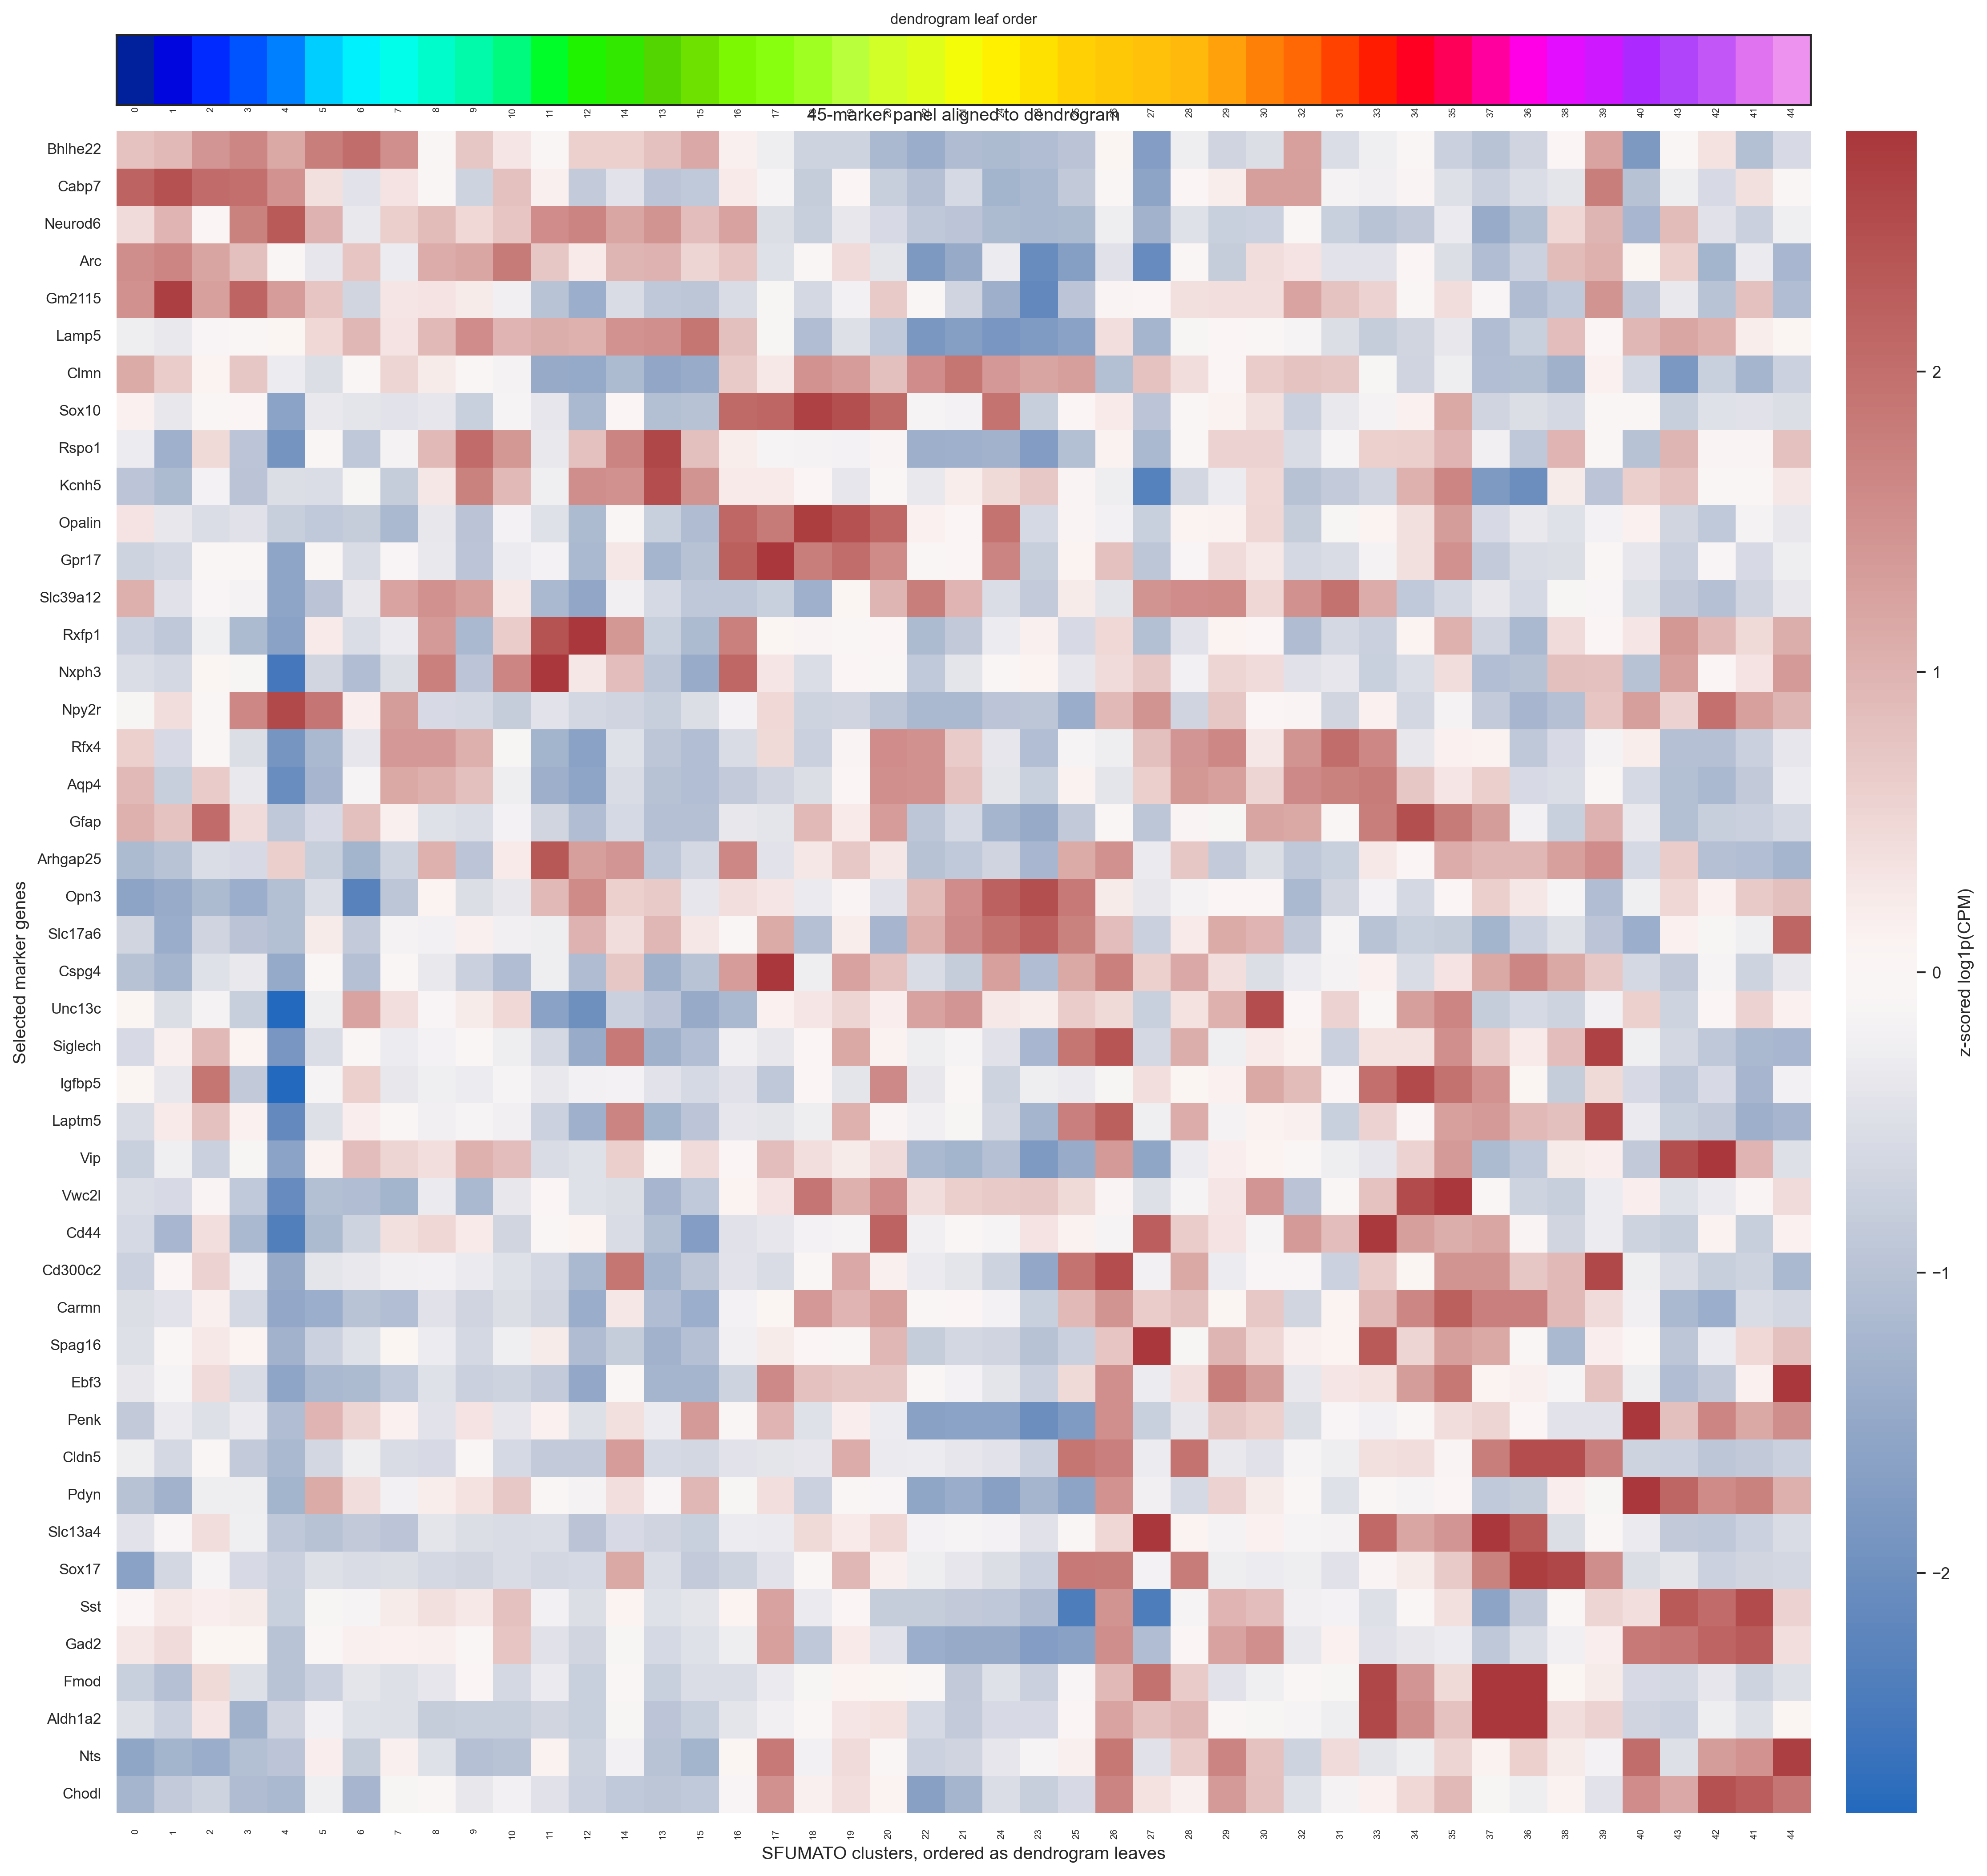

Dendrogram-ordered clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '14', '13', '15', '16', '17', '18', '19', '20', '22', '21', '24', '23', '25', '26', '27', '28', '29', '30', '32', '31', '33', '34', '35', '37', '36', '38', '39', '40', '43', '42', '41', '44']
Saved: dge_cell_level_45_outputs\heatmap_genes_by_clusters_balanced_global_45_markers_dendrogram_aligned.png
Saved: dge_cell_level_45_outputs\heatmap_genes_by_clusters_balanced_global_45_markers_dendrogram_aligned.pdf
Saved: dge_cell_level_45_outputs\gene_order_balanced_global_45_markers_dendrogram_aligned.csv


In [11]:
if len(selected_genes) == 0:
    raise ValueError("No markers were selected. Relax filters or check the input columns.")

heat = log_cpm_cluster_gene.loc[:, selected_genes].copy()
heat_z = zscore_by_gene(heat)

# ---------------------------------------------------------------------
# 1) Force the x-axis to follow the dendrogram leaf order.
# ---------------------------------------------------------------------
def _canonical_cluster_label(x):
    """Normalize cluster labels so that C17, 17, and 17.0 can match."""
    s = str(x).strip()
    if s.startswith("C") and s[1:].isdigit():
        s = s[1:]
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s

available_clusters = heat_z.index.astype(str).tolist()
available_by_canonical = {_canonical_cluster_label(c): c for c in available_clusters}

if "DENDROGRAM_CLUSTER_ORDER" not in globals() or DENDROGRAM_CLUSTER_ORDER is None:
    raise ValueError(
        "Please define DENDROGRAM_CLUSTER_ORDER in the configuration cell. "
        "It should be the left-to-right leaf order from the dendrogram."
    )

ordered_clusters = []
missing_from_data = []
for c in DENDROGRAM_CLUSTER_ORDER:
    key = _canonical_cluster_label(c)
    if key in available_by_canonical:
        ordered_clusters.append(available_by_canonical[key])
    else:
        missing_from_data.append(str(c))

# Append any clusters present in the data but absent from the manual dendrogram order.
# This makes the cell robust if a run has slightly different labels.
used = set(ordered_clusters)
extra_clusters = [c for c in available_clusters if c not in used]
if extra_clusters:
    warnings.warn(
        "Some clusters were not present in DENDROGRAM_CLUSTER_ORDER and were appended at the end: "
        + ", ".join(map(str, extra_clusters))
    )
    ordered_clusters.extend(extra_clusters)

if missing_from_data:
    warnings.warn(
        "Some DENDROGRAM_CLUSTER_ORDER entries were not found in the data and were skipped: "
        + ", ".join(missing_from_data)
    )

cluster_position = {cluster: i for i, cluster in enumerate(ordered_clusters)}

# ---------------------------------------------------------------------
# 2) Order genes by where their positive signal lies along the dendrogram.
#    This is more stable than a simple argmax for genes marking adjacent clusters.
# ---------------------------------------------------------------------
heat_gene_by_cluster = heat_z.loc[ordered_clusters, selected_genes].T
heat_pos = heat_gene_by_cluster.clip(lower=0)
xpos = np.arange(len(ordered_clusters), dtype=float)
positive_mass = heat_pos.sum(axis=1)

gene_position = pd.Series(index=heat_gene_by_cluster.index, dtype=float)
has_positive = positive_mass > 0
gene_position.loc[has_positive] = (
    heat_pos.loc[has_positive].values @ xpos
) / positive_mass.loc[has_positive].values

# Fallback for all-negative/flat genes: use the raw maximum position.
best_cluster = heat_gene_by_cluster.idxmax(axis=1)
best_cluster_position = best_cluster.map(cluster_position).astype(float)
gene_position.loc[~has_positive] = best_cluster_position.loc[~has_positive]

max_z = heat_gene_by_cluster.max(axis=1)
peak_minus_center = (best_cluster_position - gene_position).abs()

gene_order_table = pd.DataFrame({
    "gene": heat_gene_by_cluster.index,
    "dendrogram_center_of_mass": gene_position,
    "best_cluster": best_cluster,
    "best_cluster_position": best_cluster_position,
    "positive_z_mass": positive_mass,
    "max_z": max_z,
    "peak_minus_center": peak_minus_center,
}).sort_values(
    ["dendrogram_center_of_mass", "peak_minus_center", "best_cluster_position", "positive_z_mass", "max_z"],
    ascending=[True, True, True, False, False],
)
ordered_genes = gene_order_table["gene"].tolist()

# Final matrix: genes on y, dendrogram-ordered clusters on x.
heat_z_ordered = heat_gene_by_cluster.loc[ordered_genes, ordered_clusters]

# ---------------------------------------------------------------------
# 3) Plot only the dendrogram-aligned heatmap with the matching cluster colors.
# ---------------------------------------------------------------------
cluster_color_map = get_cluster_colors(obs_keep, cluster_col, color_col, clusters=available_clusters)
col_colors = [cluster_color_map[str(c)] for c in ordered_clusters]
color_arr = np.array([to_rgb(c) for c in col_colors]).reshape(1, len(col_colors), 3)

gene_order_path = OUTPUT_DIR / f"gene_order_{panel_label}_dendrogram_aligned.csv"
gene_order_table.to_csv(gene_order_path, index=False)

fig_w = max(14, 0.32 * len(ordered_clusters) + 3)
fig_h = max(7, 0.34 * len(ordered_genes) + 2)
fig = plt.figure(figsize=(fig_w, fig_h), dpi=FIG_DPI)
gs = GridSpec(2, 2, height_ratios=[0.25, 6], width_ratios=[6, 0.25], hspace=0.03, wspace=0.04, figure=fig)

ax_colors = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_colors)
cbar_ax = fig.add_subplot(gs[1, 1])
fig.add_subplot(gs[0, 1]).axis("off")

ax_colors.imshow(color_arr, aspect="auto", extent=(0, len(ordered_clusters), 0, 1), interpolation="nearest")
ax_colors.set_xlim(0, len(ordered_clusters))
ax_colors.set_ylim(0, 1)
ax_colors.set_yticks([])
ax_colors.set_xticks(np.arange(len(ordered_clusters)) + 0.5)
ax_colors.set_xticklabels(ordered_clusters, rotation=90, fontsize=5)
ax_colors.tick_params(axis="x", length=0, pad=1)
ax_colors.set_title("dendrogram leaf order", fontsize=8)

vmin=-2.8,
vmax=2.8,

sns.heatmap(
    heat_z_ordered,
    ax=ax_heat,
    cmap=HEATMAP_CMAP,
    center=0,
    vmin=-2.8,
    vmax=2.8,
    yticklabels=True,
    xticklabels=True,
    cbar_ax=cbar_ax,
    cbar_kws={"label": "z-scored log1p(CPM)"},
)

ax_heat.set_xlim(0, len(ordered_clusters))
ax_heat.set_xlabel("SFUMATO clusters, ordered as dendrogram leaves")
ax_heat.set_ylabel("Selected marker genes")
ax_heat.set_xticks(np.arange(len(ordered_clusters)) + 0.5)
ax_heat.set_xticklabels(ordered_clusters, rotation=90, fontsize=5)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=8)
ax_heat.set_title(f"{len(selected_genes)}-marker panel aligned to dendrogram")

heatmap_png = OUTPUT_DIR / f"heatmap_genes_by_clusters_{panel_label}_dendrogram_aligned.png"
heatmap_pdf = OUTPUT_DIR / f"heatmap_genes_by_clusters_{panel_label}_dendrogram_aligned.pdf"
fig.savefig(heatmap_png, bbox_inches="tight")
fig.savefig(heatmap_pdf, bbox_inches="tight")
plt.show()

print("Dendrogram-ordered clusters:", ordered_clusters)
print("Saved:", heatmap_png)
print("Saved:", heatmap_pdf)
print("Saved:", gene_order_path)
